<a href="https://colab.research.google.com/github/yaelmasterpro09-code/Equipo-8_Int.-Artificial-y-Redes-Neuronales_FIME_UANL/blob/main/AF8_RNC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Actividad 8: Redes Neuronales Convolucionales

Datos de Equipo :

Edgar Yael Martínez Pérez- 2050426

Edwin Magdaleno- Domínguez 2177965

Patricio Israel Gómez Martínez - 2062237 - N5

Giann Luca Verdeja Briones - 2050452

Materia: Inteligencia Artificial Hora: V6

1.- Importar librerias

In [ ]:
#importar librerias
import tensorflow as tf
import numpy as np
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

2.-Cargar datos.

In [ ]:
#carga de datos y division en datos de prueba y entrenamiento
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

3.-Preprocesamiento de datos.

In [ ]:
#normalizacion de los valores de los datos de prueba y de entrenamiento, en valores de 0 a 1
x_train, x_test= x_train / 255.0, x_test / 255.0

In [ ]:
# agregar una dimension extra a los datos
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)


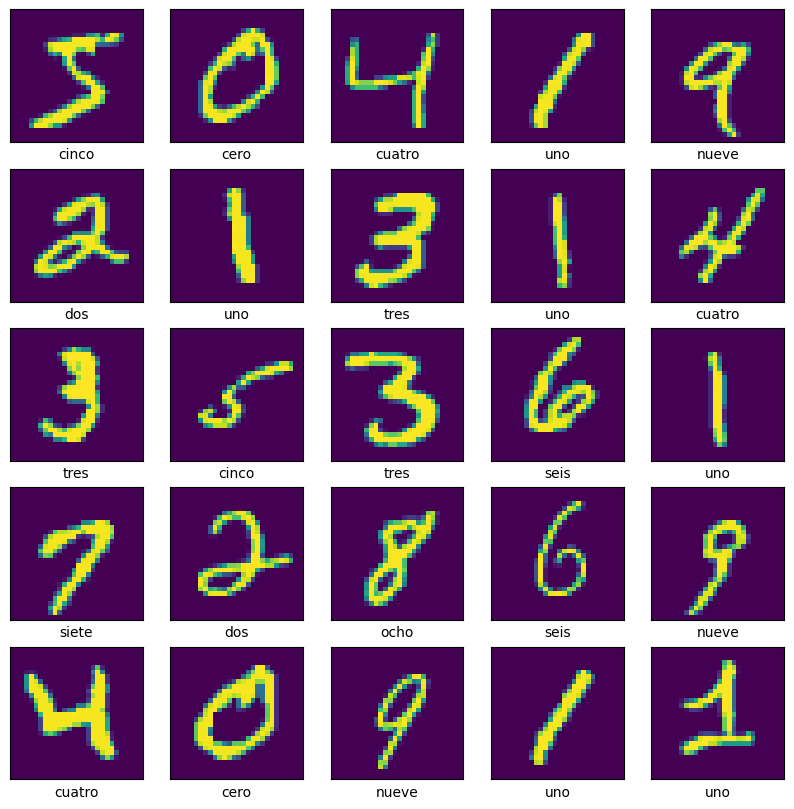

In [ ]:
#muestra de etiquetas y imagenes de entrenamiento
class_names = ['cero', 'uno','dos','tres','cuatro','cinco','seis','siete','ocho','nueve']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])

    plt.xlabel(class_names[y_train[i]])
plt.show()

4.-Selección y entrenamiento del modelo.

In [ ]:
#definicion del modelo
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#estructura del modelo
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,744 (217.75 KB)

 Trainable params: 55,744 (217.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#finalizacion del modelo
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

In [ ]:
#estructura del modelo completo
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#configuracion de reglas de aprendizaje
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:

#definicion de epocas de entrenamiento y grupos

history = model.fit(x_train, y_train, batch_size=128, epochs=15, validation_split=0.2)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


375/375 ━━━━━━━━━━━━━━━━━━━━ 46s 117ms/step - accuracy: 0.9093 - loss: 0.2909 - val_accuracy: 0.9738 - val_loss: 0.0886
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 44s 116ms/step - accuracy: 0.9786 - loss: 0.0692 - val_accuracy: 0.9795 - val_loss: 0.0660
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.9855 - loss: 0.0463 - val_accuracy: 0.9833 - val_loss: 0.0536
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 114ms/step - accuracy: 0.9889 - loss: 0.0360 - val_accuracy: 0.9872 - val_loss: 0.0444
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - accuracy: 0.9908 - loss: 0.0278 - val_accuracy: 0.9838 - val_loss: 0.0549
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 45s 120ms/step - accuracy: 0.9919 - loss: 0.0251 - val_accuracy: 0.9850 - val_loss: 0.0493
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - accuracy: 0.9932 - loss: 0.0200 - val_accuracy: 0.9893 - val_loss: 0.0395
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 83s 114ms/step - accuracy: 0.9947 - loss: 0.0166 - val

313/313 - 3s - 9ms/step - accuracy: 0.9901 - loss: 0.0406


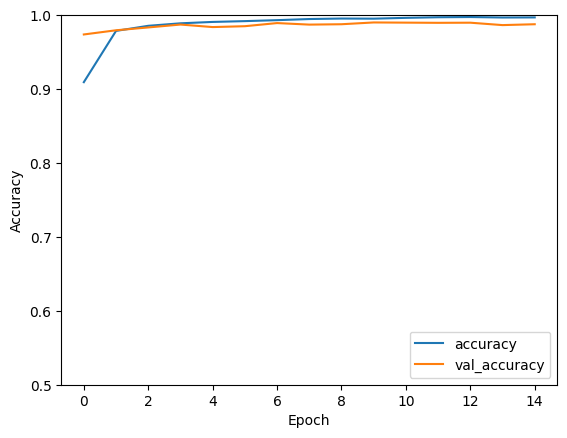

In [ ]:
#grafica de precision del modelo
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

In [ ]:

#evaluacion de exactitud del modelo con imagenes de prueba
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Exactitud en conjunto de prueba: {test_acc:.4f}")

Exactitud en conjunto de prueba: 0.9901


5.-Prueba del modelo.

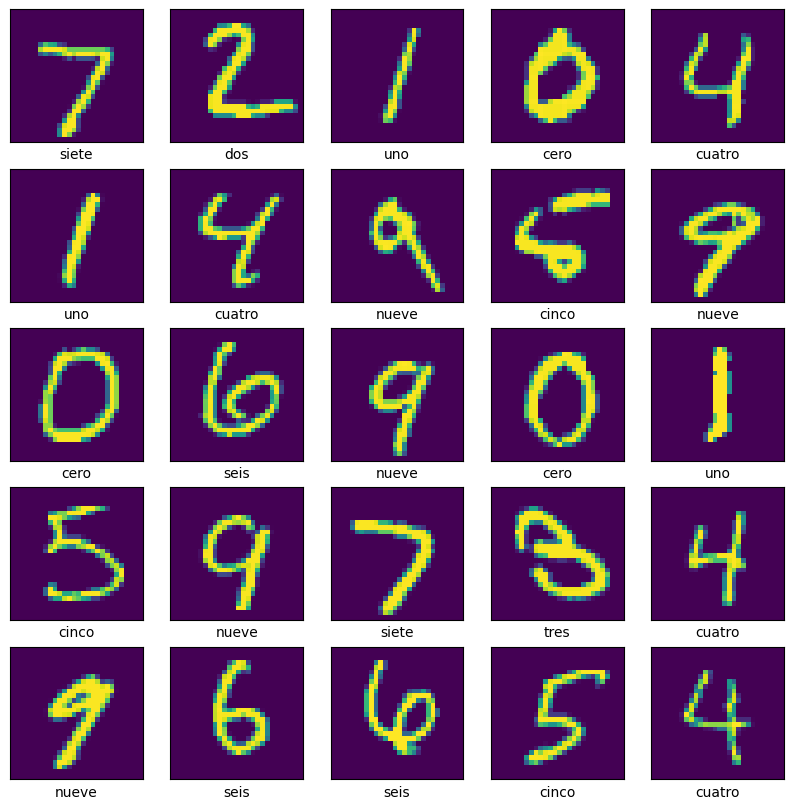

In [ ]:
#prediccion de 25 imagenes de prueba
class_names = ['cero', 'uno','dos','tres','cuatro','cinco','seis','siete','ocho','nueve']
prueba = model.predict(x_test[:25], verbose=0)
clase = np.argmax(prueba, axis=1)
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[i])
    plt.xlabel(class_names[clase[i]])
plt.show()